# Assignment 4: Regularization

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?

- Adding a penalty on coefficient sizes forces the model to balance both fitting the data well and keeping coefficients small. The penalty discourages large coefficients that would mean an overly sensitive model to noise.

2. How does regularization provide a way of exploring the bias-variance trade-off?

- Increasing alpha helps to shrink coefficients more aggressively. At a low alpha value, you get low bias but high variance exageratting the trade off. As alpha increases, variance decreases but more bias is introduced.

3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?

- Ridge penalizes the sum of squared coefficients, shrinking all of them toward zero but never exactly to zero, so every variable stays in the model. This contrasts with the Lasso model which penalizes the sum of absolute values and can actually shrink variables to zero, therefore removing quite a few variables.

4. How do we typically scale variables for use in regularized regression? Why?

- We typically standardize with a mean of zero and standard deviation of one. This is done to essentially level the playing field so that large scale and small scale variables both feel the penalty equally.

5. How is the penalty $\alpha$ typically selected?

- It is chosen by cross-validation over a grid of calculated values and the one with the lowest CV error is chosen.

6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

- No, CV measures the predictive capability of a model on data and has nothing to do with the penalty.


**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them.
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?

- It is -1671212.36.

3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?

- Age^2 is the only feature set to zero. All others features are selected with only an 11% proportion set to zero.

7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

- No coefficients increase in magnitude as all of them shrink toward zero as expected. Two coefficients change sign being Age^2, which is zeroed out as mentioned earlier, and Age^3, which flips from negative to positive. This suggests that OLS estimates for these terms were unstable due to multicollinearity among the polynomial features.


In [1]:
import urllib.request
import os
import zipfile
import os

def download_data(force=False):
    """Download and extract course data from Zenodo."""

    zip_path = 'data.zip'
    data_dir = './data'

    if not os.path.exists(zip_path) or force:
        print("Downloading course data...")
        urllib.request.urlretrieve(
            'https://zenodo.org/records/18235955/files/data.zip?download=1',
            zip_path
        )
        print("Download complete")

    if not os.path.exists(data_dir) or force:
        print("Extracting data files...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(data_dir)
        print("Data extracted")

    return data_dir


if __name__ == "__main__":
    download_data()

Download complete
Extracting data files...
Data extracted


In [18]:
# 2.1

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV, lasso_path
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

vehicles = pd.read_csv("/content/data/cars_hw.csv")

# Create Age variable and X and Y variables
vehicles["Age"] = 2026 - vehicles["Make_Year"]

X_input = vehicles[["Mileage_Run", "Age"]]
y_target = vehicles["Price"]

# Create polynomial features
poly_transformer = PolynomialFeatures(degree=3, include_bias=False)
std_scaler = StandardScaler()

X_poly_transformed = poly_transformer.fit_transform(X_input)
X_normalized = std_scaler.fit_transform(X_poly_transformed)

feature_names = poly_transformer.get_feature_names_out(["Mileage_Run", "Age"])



In [19]:
# 2.2

# Create linear regression model
ols_model = LinearRegression()
ols_model.fit(X_normalized, y_target)

ols_coefs = pd.Series(ols_model.coef_, index=feature_names)
print(ols_coefs)

# Check sign of interaction term
print("\nInteraction coefficient sign:")
print(ols_coefs["Mileage_Run Age"])

Mileage_Run          9.117748e+05
Age                 -2.481722e+05
Mileage_Run^2       -2.072926e+05
Mileage_Run Age     -1.671212e+06
Age^2                3.505507e+05
Mileage_Run^3       -6.514490e+04
Mileage_Run^2 Age    3.388195e+05
Mileage_Run Age^2    7.167816e+05
Age^3               -2.100379e+05
dtype: float64

Interaction coefficient sign:
-1671212.3563918793


In [20]:
# 2.3

# Run regression for range of alpha values
alpha_grid = np.logspace(1, 3, 20)

lasso_model = LassoCV(alphas=alpha_grid, cv=20, max_iter=50000)
lasso_model.fit(X_normalized, y_target)

print("Optimal alpha:", lasso_model.alpha_)

Optimal alpha: 88.58667904100822


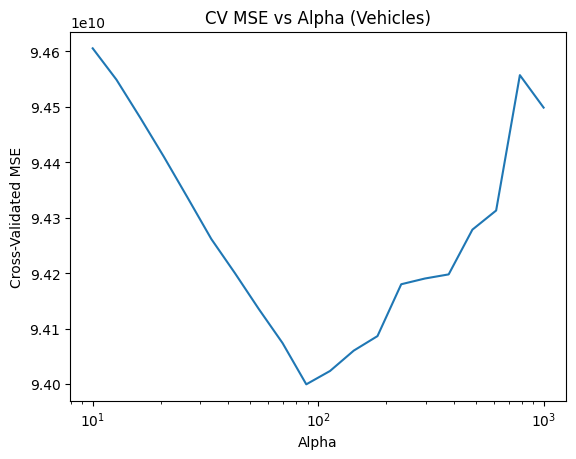

In [21]:
# 2.4

avg_mse = np.mean(lasso_model.mse_path_, axis=1)

# Plot MSE against alpha
plt.figure()
plt.plot(lasso_model.alphas_, avg_mse)
plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("Cross-Validated MSE")
plt.title("CV MSE vs Alpha (Vehicles)")
plt.show()

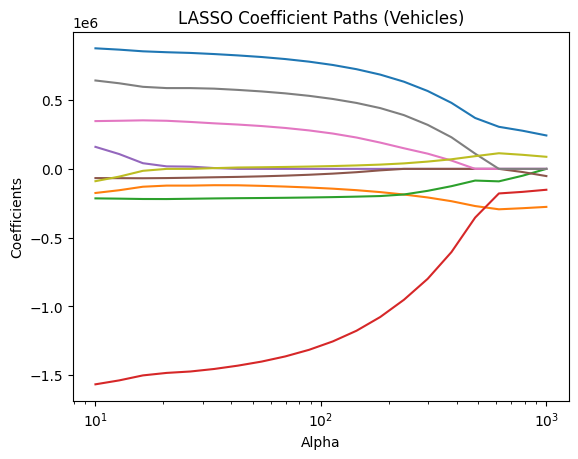

In [22]:
# 2.5

# Get coefficients at each alpha value
path_alphas, path_coefs, _ = lasso_path(
    X_normalized,
    y_target,
    alphas=alpha_grid,
    max_iter=50000
)

# Plot LASSO coefficient paths at values of alpha
plt.figure()
for idx in range(path_coefs.shape[0]):
    plt.plot(path_alphas, path_coefs[idx])
plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("Coefficients")
plt.title("LASSO Coefficient Paths (Vehicles)")
plt.show()

In [23]:
# 2.6

# Get coefficients at optimal alpha
lasso_coefs = pd.Series(lasso_model.coef_, index=feature_names)

retained_features = lasso_coefs[lasso_coefs != 0]

print("Selected Features:")
print(retained_features)

# Calculate proportion of dropped features
dropped_features = lasso_coefs[lasso_coefs == 0]
print("\nProportion set to zero:",
      len(dropped_features) / len(lasso_coefs))


Selected Features:
Mileage_Run          7.790762e+05
Age                 -1.339534e+05
Mileage_Run^2       -2.015634e+05
Mileage_Run Age     -1.322419e+06
Mileage_Run^3       -4.240952e+04
Mileage_Run^2 Age    2.715062e+05
Mileage_Run Age^2    5.415432e+05
Age^3                1.374220e+04
dtype: float64

Proportion set to zero: 0.1111111111111111


In [24]:
# 2.7

# Create and display dataframe to compare LASSO and OLS
coef_comparison = pd.DataFrame({
    "OLS": ols_coefs,
    "LASSO": lasso_coefs
})

coef_comparison["Sign Change"] = np.sign(coef_comparison["OLS"]) != np.sign(coef_comparison["LASSO"])
coef_comparison["Magnitude Increased"] = abs(coef_comparison["LASSO"]) > abs(coef_comparison["OLS"])

coef_comparison.sort_values("LASSO").head(10)

,OLS,LASSO,Sign Change,Magnitude Increased
Mileage_Run Age,-1.671212e+06,-1.322419e+06,False,False
Mileage_Run^2,-2.072926e+05,-2.015634e+05,False,False
Age,-2.481722e+05,-1.339534e+05,False,False
Mileage_Run^3,-6.514490e+04,-4.240952e+04,False,False
Age^2,3.505507e+05,0.000000e+00,True,False
Age^3,-2.100379e+05,1.374220e+04,True,False
Mileage_Run^2 Age,3.388195e+05,2.715062e+05,False,False
Mileage_Run Age^2,7.167816e+05,5.415432e+05,False,False
Mileage_Run,9.117748e+05,7.790762e+05,False,False


**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?

- There appear to be some counterintuitive signs such as age being positive while age^2 is negative despite older patients facing more health risks. Also diabetes, high blood pressure, and smoking are all negative despite being objectively negative health risks. However, he model captures nonlinear relationships through higher-order terms so no single coefficient can be interpreted in isolation.

3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

- LASSO selected 12 of 29 features, zeroing out 58.6%. Only anemia increased in magnitude while the rest shrank. The signs of coefficients given by LASSO are more interpretable as it trades a small amount of bias for a much larger reduction in variance. The resulting model is more stable whose coefficients reflect genuine relationships.


In [26]:
# 3.1

heart_df = pd.read_csv("/content/data/heart_failure_clinical_records_dataset.csv")

# Create polynomial features and interaction terms
y_target = heart_df["DEATH_EVENT"]
cont_cols = ["age", "ejection_fraction", "serum_creatinine"]
poly_cont = PolynomialFeatures(degree=3, include_bias=False)
X_cont_transformed = poly_cont.fit_transform(heart_df[cont_cols])
cont_feature_names = poly_cont.get_feature_names_out(cont_cols)

binary_cols = ["anaemia", "diabetes", "high_blood_pressure", "smoking"]
poly_binary = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_binary_inter = poly_binary.fit_transform(heart_df[binary_cols])
binary_feature_names = poly_binary.get_feature_names_out(binary_cols)

# Combine variables and scale them
X_full = np.hstack([X_cont_transformed, X_binary_inter])
all_features = list(cont_feature_names) + list(binary_feature_names)

std_scaler = StandardScaler()
X_normalized = std_scaler.fit_transform(X_full)


In [27]:
# 3.2

# Run linear regression on heart model
ols_model = LinearRegression()
ols_model.fit(X_normalized, y_target)

ols_coefs = pd.Series(ols_model.coef_, index=all_features)
print(ols_coefs.sort_values())

age^2                                    -3.678654
serum_creatinine^2                       -2.647041
ejection_fraction                        -2.192494
age ejection_fraction serum_creatinine   -1.577665
ejection_fraction^2 serum_creatinine     -1.270043
ejection_fraction^3                      -1.250341
serum_creatinine                         -0.853588
age^2 serum_creatinine                   -0.697522
age ejection_fraction                    -0.600918
age ejection_fraction^2                  -0.081206
smoking                                  -0.047943
diabetes                                 -0.034875
anaemia high_blood_pressure              -0.010004
high_blood_pressure                      -0.003787
anaemia                                   0.004008
anaemia diabetes                          0.009990
anaemia smoking                           0.020606
high_blood_pressure smoking               0.030482
diabetes high_blood_pressure              0.046474
diabetes smoking               

In [28]:
# 3.3

# Run LASSO model
alpha_grid = np.logspace(-5, 5, 30)

lasso_model = LassoCV(alphas=alpha_grid, cv=20, max_iter=100000)
lasso_model.fit(X_normalized, y_target)

print("Optimal alpha:", lasso_model.alpha_)

Optimal alpha: 0.005736152510448681


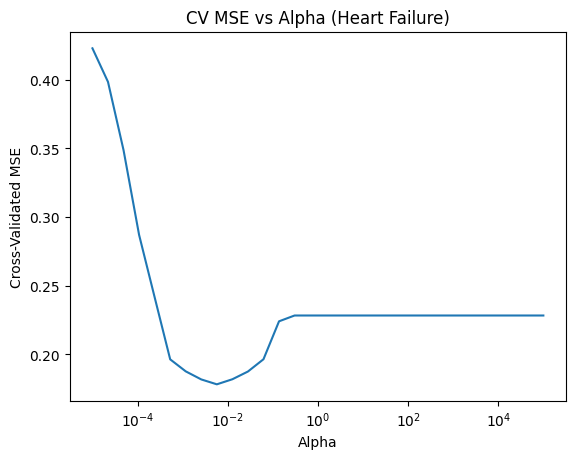

In [29]:
# 3.4

# Calculate MSE as alpha varies
avg_mse = np.mean(lasso_model.mse_path_, axis=1)

# Plot MSE against alpha
plt.figure()
plt.plot(lasso_model.alphas_, avg_mse)
plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("Cross-Validated MSE")
plt.title("CV MSE vs Alpha (Heart Failure)")
plt.show()

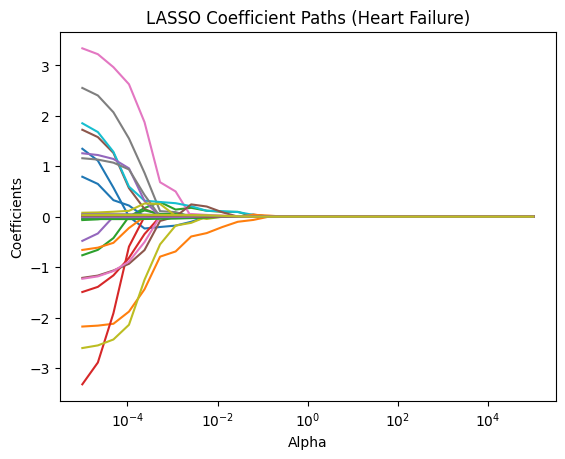

In [30]:
# 3.5

# Get coefficients for each value of alpha
path_alphas, path_coefs, _ = lasso_path(
    X_normalized,
    y_target,
    alphas=alpha_grid,
    max_iter=100000
    )

# Plot coefficient paths for heart dataset
plt.figure()
for idx in range(path_coefs.shape[0]):
    plt.plot(path_alphas, path_coefs[idx])

plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("Coefficients")
plt.title("LASSO Coefficient Paths (Heart Failure)")
plt.show()

In [31]:
# 3.6

# Get coefficients for optimal alpha
lasso_coefs = pd.Series(lasso_model.coef_, index=all_features)

retained_features = lasso_coefs[lasso_coefs != 0]

print("Selected Features:")
print(retained_features)

# Calculate proportion of parameters dropped
dropped_features = lasso_coefs[lasso_coefs == 0]

print("\nProportion set to zero:",
      len(dropped_features) / len(lasso_coefs))

# Create table to compare LASSO and OLS
coef_comparison = pd.DataFrame({
    "OLS": ols_coefs,
    "LASSO": lasso_coefs
})

coef_comparison["Sign Change"] = np.sign(coef_comparison["OLS"]) != np.sign(coef_comparison["LASSO"])
coef_comparison["Magnitude Increased"] = abs(coef_comparison["LASSO"]) > abs(coef_comparison["OLS"])

coef_comparison.sort_values("LASSO").head(30)

Selected Features:
ejection_fraction                      -0.326124
serum_creatinine                        0.117426
age^3                                   0.116214
ejection_fraction^3                     0.200750
ejection_fraction^2 serum_creatinine    0.034419
serum_creatinine^3                     -0.045558
anaemia                                 0.013163
smoking                                -0.019828
anaemia diabetes                        0.000310
diabetes high_blood_pressure            0.024535
diabetes smoking                        0.017410
high_blood_pressure smoking             0.025812
dtype: float64

Proportion set to zero: 0.5862068965517241


,OLS,LASSO,Sign Change,Magnitude Increased
ejection_fraction,-2.192494,-0.326124,False,False
serum_creatinine^3,0.072156,-0.045558,True,False
smoking,-0.047943,-0.019828,False,False
age,1.539156,-0.000000,True,False
ejection_fraction^2,3.430976,0.000000,True,False
age serum_creatinine,1.841563,0.000000,True,False
age^2,-3.678654,0.000000,True,False
age ejection_fraction,-0.600918,-0.000000,True,False
age serum_creatinine^2,1.284099,-0.000000,True,False
age^2 ejection_fraction,0.908026,0.000000,True,False


**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?

- $$L = \frac{1}{n} \sum_{i=1}^n (\tilde{y}_i - b_0 - b_1 \tilde{x}_i)^2 + \alpha b_1^2$$

2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.

- Taking the derivative with respect to $b_0$:

$$
\frac{\partial}{\partial b_0} = -\frac{2}{n} \sum_{i=1}^n (\tilde{y}_i - b_0 - b_1 \tilde{x}_i) = 0
$$

Solving gives:

$$
b_0 = 0
$$

Taking the derivative with respect to $b_1$:

$$
\frac{\partial}{\partial b_1} = -\frac{2}{n} \sum_{i=1}^n \tilde{x}_i (\tilde{y}_i - b_1 \tilde{x}_i) + 2\alpha b_1 = 0
$$

Solving for $b_1$:

$$
b_1 = \frac{\frac{1}{n}\sum \tilde{x}_i \tilde{y}_i}{\frac{1}{n}\sum \tilde{x}_i^2 + \alpha}
$$

3. How does increasing $\alpha$ change the slope coefficient?

- As alpha increases, the denominator gets bigger and the slope gets closer to zero.

4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

- The challenge is that the absolute value of b1 is not differentiable at zero. It is optimal to set b1 equal to 0 when the correlation between the predictor and residuals is small enough to fall within the flat region of the penalty. This is why LASSO produces exact zeros while Ridge does not.
